# STEP 1 — MOUNT GOOGLE DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


STEP 2 — IMPORT LIBRARIES


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

from PIL import Image

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Dropout, BatchNormalization

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.optimizers import Adam, SGD

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

STEP 3 — DATASET PATH

In [ ]:
# Set dataset path

dataset_path = "/content/drive/MyDrive/ai&ml_assessment/facial expression classification-20260506T194443Z-3-001/facial expression classification"

train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

 STEP 4 — CHECK DATASET

In [ ]:
print("Train Classes:\n")
print(os.listdir(train_dir))

print("\nTest Classes:\n")
print(os.listdir(test_dir))

Train Classes:

['sad', 'fear', 'neutral', 'surprise', 'angry', 'happy', 'disgust']

Test Classes:

['sad', 'neutral', 'angry', 'happy', 'disgust', 'surprise', 'fear']


STEP 5 — DISPLAY NUMBER OF IMAGES

In [ ]:
print("\nNumber of Images in Each Class:\n")

for category in os.listdir(train_dir):

    category_path = os.path.join(train_dir, category)

    print(category, ":", len(os.listdir(category_path)))



Number of Images in Each Class:

sad : 4633
fear : 3803
neutral : 4675
surprise : 2898
angry : 3686
happy : 6859
disgust : 329


STEP 6 — SHOW SAMPLE IMAGES

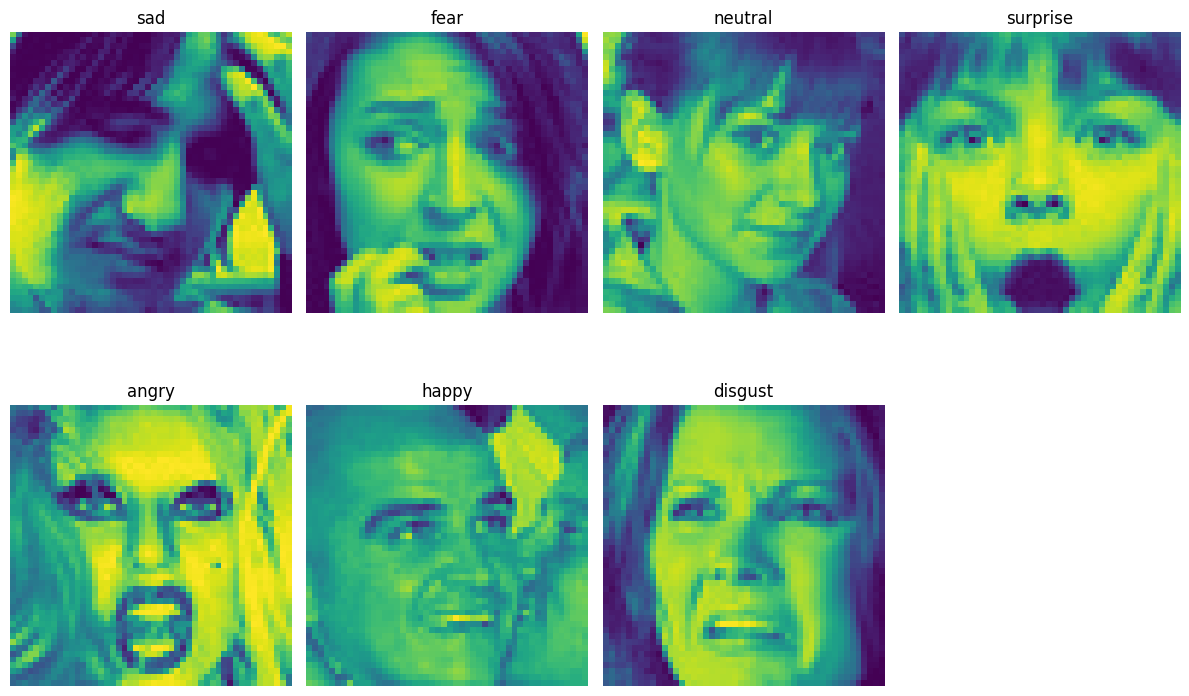

In [ ]:
plt.figure(figsize=(12,8))

i = 1

for category in os.listdir(train_dir):

    category_path = os.path.join(train_dir, category)

    # Skip if not folder
    if not os.path.isdir(category_path):
        continue

    image_files = os.listdir(category_path)

    # Skip empty folders
    if len(image_files) == 0:
        print(f"No images found in {category}")
        continue

    img_path = os.path.join(category_path, image_files[0])

    try:

        img = Image.open(img_path)

        plt.subplot(2,4,i)

        plt.imshow(img)

        plt.title(category)

        plt.axis("off")

        i += 1

    except Exception as e:

        print(f"Error loading image from {category}: {e}")

plt.tight_layout()

plt.show()

In [ ]:
# Check dataset folders

for category in os.listdir(train_dir):

    category_path = os.path.join(train_dir, category)

    if os.path.isdir(category_path):

        print(category, "->", len(os.listdir(category_path)))

sad -> 4633
fear -> 3803
neutral -> 4675
surprise -> 2898
angry -> 3686
happy -> 6859
disgust -> 329


STEP 7 — DATA PREPROCESSING & AUGMENTATION

In [ ]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True

)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
# ============================================================
# REMOVE CORRUPTED / INVALID IMAGES
# ============================================================

from PIL import Image

valid_extensions = ('.jpg', '.jpeg', '.png')

removed_files = []

for folder_path in [train_dir, test_dir]:

    for category in os.listdir(folder_path):

        category_path = os.path.join(folder_path, category)

        if not os.path.isdir(category_path):
            continue

        for file_name in os.listdir(category_path):

            file_path = os.path.join(category_path, file_name)

            try:

                # Check valid extension
                if not file_name.lower().endswith(valid_extensions):

                    os.remove(file_path)

                    removed_files.append(file_path)

                    continue

                # Try opening image
                img = Image.open(file_path)

                img.verify()

            except Exception:

                os.remove(file_path)

                removed_files.append(file_path)

print("Removed files:")

for file in removed_files:
    print(file)

print("\nDataset cleaned successfully.")

Removed files:
/content/drive/MyDrive/ai&ml_assessment/facial expression classification-20260506T194443Z-3-001/facial expression classification/train/sad/35718.jpg
/content/drive/MyDrive/ai&ml_assessment/facial expression classification-20260506T194443Z-3-001/facial expression classification/train/sad/33969.jpg
/content/drive/MyDrive/ai&ml_assessment/facial expression classification-20260506T194443Z-3-001/facial expression classification/train/fear/20859.jpg
/content/drive/MyDrive/ai&ml_assessment/facial expression classification-20260506T194443Z-3-001/facial expression classification/train/fear/16790.jpg
/content/drive/MyDrive/ai&ml_assessment/facial expression classification-20260506T194443Z-3-001/facial expression classification/train/fear/28654.jpg
/content/drive/MyDrive/ai&ml_assessment/facial expression classification-20260506T194443Z-3-001/facial expression classification/train/fear/14992.jpg
/content/drive/MyDrive/ai&ml_assessment/facial expression classification-20260506T19444

STEP 8 — CREATE DATA GENERATORS

In [ ]:
train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=(48,48),

    batch_size=64,

    class_mode='categorical',

    subset='training'

)

validation_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=(48,48),

    batch_size=64,

    class_mode='categorical',

    subset='validation'

)

test_generator = test_datagen.flow_from_directory(

    test_dir,

    target_size=(48,48),

    batch_size=64,

    class_mode='categorical',

    shuffle=False

)

Found 21502 images belonging to 7 classes.
Found 5372 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.


STEP 9 — BUILD BASELINE CNN MODEL

In [ ]:
model = Sequential()

# Input Layer
model.add(Input(shape=(48,48,3)))

# Convolution Layer 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(2,2))


# Convolution Layer 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(2,2))


# Convolution Layer 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(2,2))


# Flatten
model.add(Flatten())


# Fully Connected Layers
model.add(Dense(128, activation='relu'))

model.add(Dense(64, activation='relu'))

model.add(Dense(32, activation='relu'))


# Output Layer
model.add(
    Dense(
        train_generator.num_classes,
        activation='softmax'
    )
)

STEP 10 — MODEL SUMMARY

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 366,087 (1.40 MB)

 Trainable params: 366,087 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

STEP 11 — COMPILE MODEL

In [ ]:
model.compile(

    optimizer=Adam(),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

STEP 12 — TRAIN BASELINE MODEL

In [ ]:
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=10

)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 275s 809ms/step - accuracy: 0.2622 - loss: 1.7877 - val_accuracy: 0.2960 - val_loss: 1.7243
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 218s 648ms/step - accuracy: 0.3452 - loss: 1.6481 - val_accuracy: 0.3617 - val_loss: 1.6138
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 214s 638ms/step - accuracy: 0.4060 - loss: 1.5279 - val_accuracy: 0.4030 - val_loss: 1.5060
Epoch 4/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 216s 642ms/step - accuracy: 0.4367 - loss: 1.4540 - val_accuracy: 0.4276 - val_loss: 1.4425
Epoch 5/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 220s 655ms/step - accuracy: 0.4657 - loss: 1.3883 - val_accuracy: 0.4587 - val_loss: 1.3948
Epoch 6/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 214s 637ms/step - accuracy: 0.4814 - loss: 1.3456 - val_accuracy: 0.4803 - val_loss: 1.3271
Epoch 7/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 216s 643ms/step - accuracy: 0.5018 - loss: 1.3038 - val_accuracy: 0.4847 - val_loss: 1.3099
Epoch 8/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 217s 646ms/step - accuracy: 0.5143 -

STEP 13 — PLOT ACCURACY GRAPH

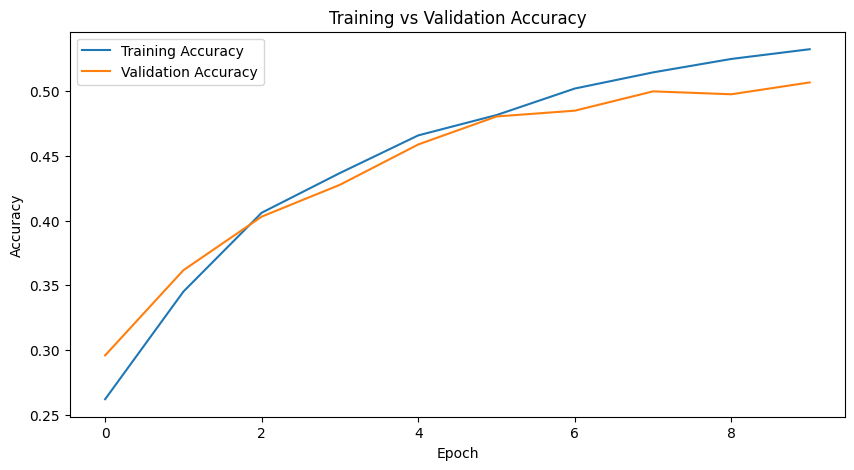

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

 STEP 14 — PLOT LOSS GRAPH

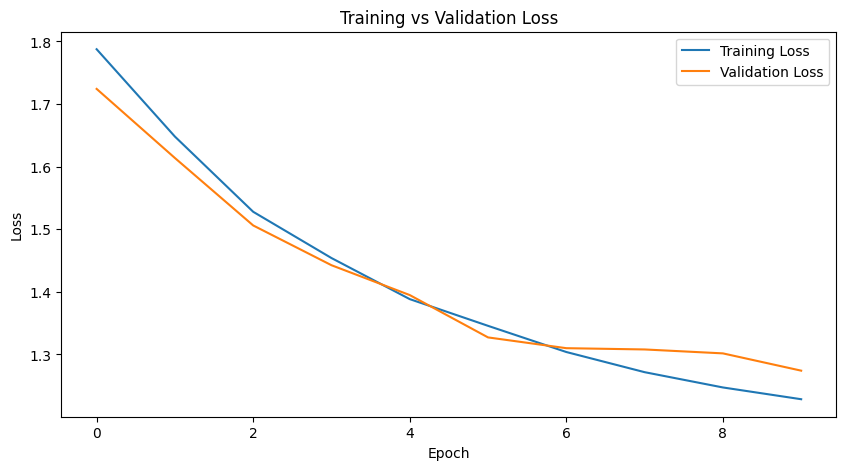

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

STEP 15 — EVALUATE BASELINE MODEL

In [ ]:
predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

print("\nClassification Report:\n")

print(
    classification_report(
        true_classes,
        predicted_classes
    )
)

30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 346ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.38      0.52      0.44       300
           1       0.00      0.00      0.00       100
           2       0.40      0.14      0.21       300
           3       0.56      0.82      0.66       300
           4       0.39      0.63      0.48       300
           5       0.39      0.26      0.31       300
           6       0.75      0.62      0.68       300

    accuracy                           0.47      1900
   macro avg       0.41      0.43      0.40      1900
weighted avg       0.45      0.47      0.44      1900



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


STEP 16 — CONFUSION MATRIX

In [ ]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print("\nConfusion Matrix:\n")

print(cm)


Confusion Matrix:

[[157   0  12  41  54  27   9]
 [ 51   0   9   7  19  12   2]
 [ 82   0  42  33  64  45  34]
 [ 19   0   4 247  21   5   4]
 [ 28   0   6  39 188  29  10]
 [ 57   0  10  46 104  79   4]
 [ 24   0  22  30  32   6 186]]


STEP 17 — SHOW SAMPLE PREDICTIONS

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


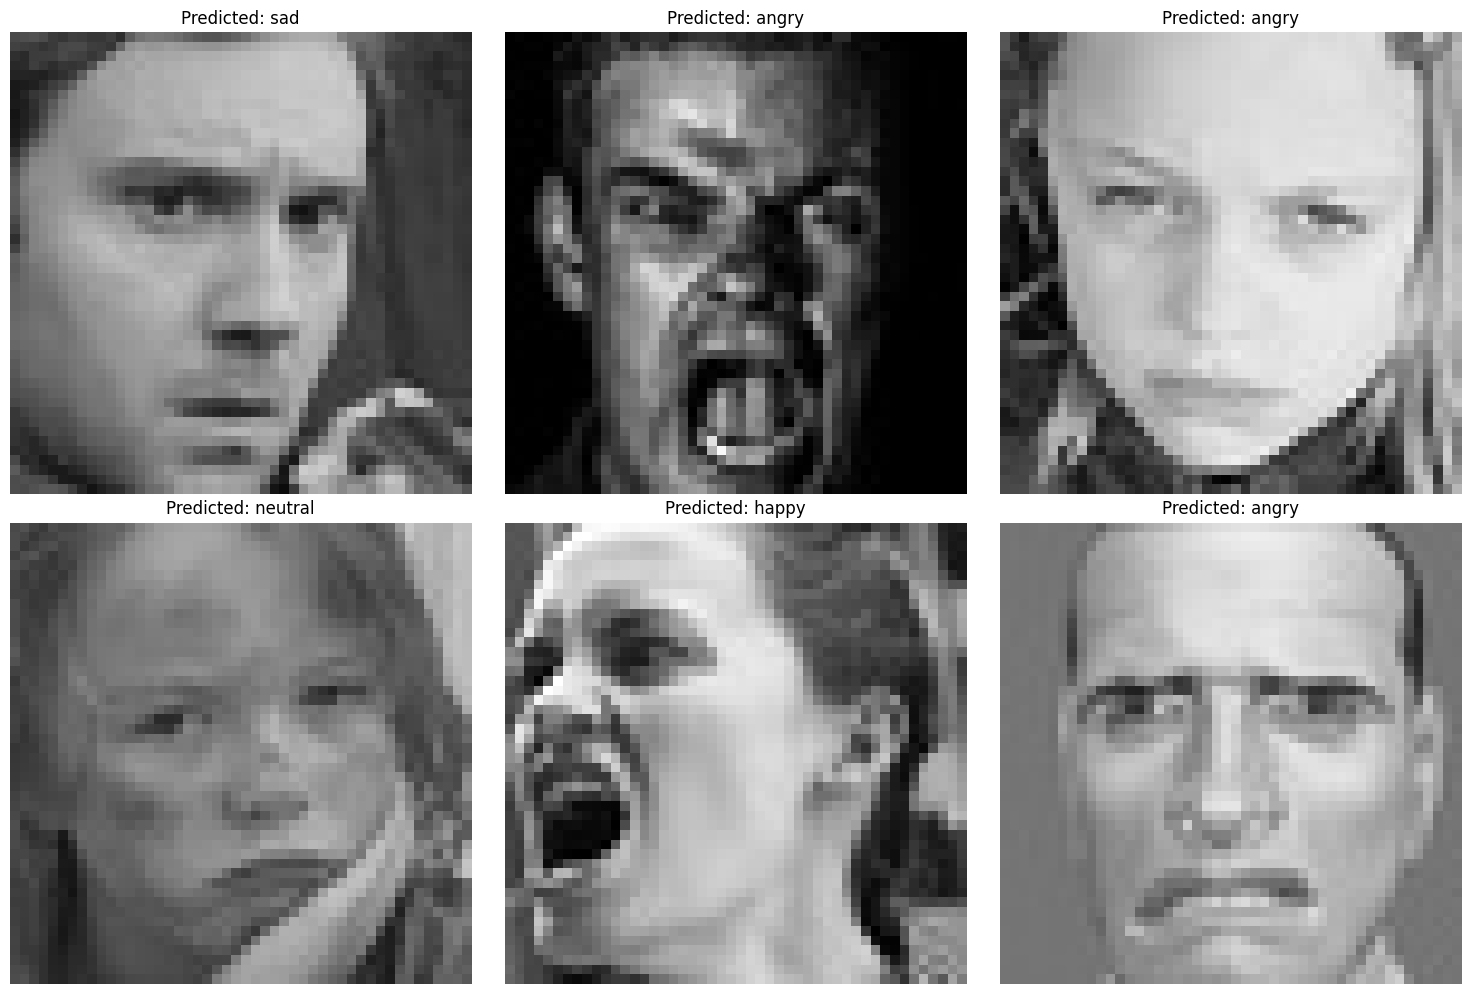

In [ ]:
class_labels = list(test_generator.class_indices.keys())

print(class_labels)

plt.figure(figsize=(15,10))

for i in range(6):

    img, label = test_generator[i]

    prediction = model.predict(img)

    predicted_index = np.argmax(prediction[0])

    predicted_label = class_labels[predicted_index]

    plt.subplot(2,3,i+1)

    plt.imshow(img[0])

    plt.title("Predicted: " + predicted_label)

    plt.axis("off")

plt.tight_layout()

plt.show()

STEP 18 — BUILD DEEPER CNN MODEL

In [ ]:
# Deeper CNN with Batch Normalization & Dropout

model2 = Sequential()


# Layer 1

model2.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(48,48,3)
    )
)

model2.add(BatchNormalization())

model2.add(MaxPooling2D(2,2))


# Layer 2

model2.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model2.add(BatchNormalization())

model2.add(MaxPooling2D(2,2))


# Layer 3

model2.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model2.add(BatchNormalization())

model2.add(MaxPooling2D(2,2))


# Layer 4

model2.add(
    Conv2D(
        256,
        (3,3),
        activation='relu'
    )
)

model2.add(BatchNormalization())

model2.add(MaxPooling2D(2,2))


# Flatten

model2.add(Flatten())


# Dense Layers

model2.add(Dense(256, activation='relu'))

model2.add(Dropout(0.3))

model2.add(Dense(128, activation='relu'))

model2.add(Dense(
    train_generator.num_classes,
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


STEP 19 — DEEPER MODEL SUMMARY

In [ ]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 2, 2, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,927 (1.87 MB)

 Trainable params: 488,967 (1.87 MB)

 Non-trainable params: 960 (3.75 KB)

STEP 20 — TRAIN USING ADAM

In [ ]:
model2.compile(

    optimizer=Adam(),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

history2 = model2.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=10

)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 285s 820ms/step - accuracy: 0.3462 - loss: 1.6429 - val_accuracy: 0.2373 - val_loss: 1.7969
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 263s 782ms/step - accuracy: 0.4290 - loss: 1.4751 - val_accuracy: 0.4090 - val_loss: 1.5602
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 272s 809ms/step - accuracy: 0.4716 - loss: 1.3744 - val_accuracy: 0.3842 - val_loss: 1.5625
Epoch 4/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 259s 772ms/step - accuracy: 0.4996 - loss: 1.3057 - val_accuracy: 0.4684 - val_loss: 1.3913
Epoch 5/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 258s 766ms/step - accuracy: 0.5143 - loss: 1.2656 - val_accuracy: 0.3034 - val_loss: 1.7122
Epoch 6/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 258s 766ms/step - accuracy: 0.5327 - loss: 1.2258 - val_accuracy: 0.4630 - val_loss: 1.4078
Epoch 7/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 255s 759ms/step - accuracy: 0.5425 - loss: 1.2024 - val_accuracy: 0.5223 - val_loss: 1.2520
Epoch 8/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 265s 768ms/step - accuracy: 0.5499 -

STEP 21 — TRAIN USING SGD

In [ ]:
model2.compile(

    optimizer=SGD(),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

history_sgd = model2.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=10

)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 273s 806ms/step - accuracy: 0.5879 - loss: 1.0976 - val_accuracy: 0.5007 - val_loss: 1.3158
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 256s 762ms/step - accuracy: 0.5881 - loss: 1.0824 - val_accuracy: 0.5136 - val_loss: 1.2720
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 260s 773ms/step - accuracy: 0.5938 - loss: 1.0759 - val_accuracy: 0.5350 - val_loss: 1.2156
Epoch 4/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 261s 776ms/step - accuracy: 0.5960 - loss: 1.0637 - val_accuracy: 0.4803 - val_loss: 1.3639
Epoch 5/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 262s 779ms/step - accuracy: 0.5990 - loss: 1.0581 - val_accuracy: 0.5192 - val_loss: 1.2548
Epoch 6/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 257s 763ms/step - accuracy: 0.5979 - loss: 1.0601 - val_accuracy: 0.5594 - val_loss: 1.1599
Epoch 7/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 262s 763ms/step - accuracy: 0.5980 - loss: 1.0519 - val_accuracy: 0.5089 - val_loss: 1.2973
Epoch 8/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 254s 754ms/step - accuracy: 0.6022 -

STEP 22 — TRANSFER LEARNING (VGG16)

In [ ]:
from tensorflow.keras.applications import VGG16


# Load VGG16 Base Model

base_model = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(48,48,3)

)


# Freeze Layers

for layer in base_model.layers:

    layer.trainable = False


# Create Transfer Learning Model

transfer_model = Sequential()

transfer_model.add(base_model)

transfer_model.add(Flatten())

transfer_model.add(Dense(128, activation='relu'))

transfer_model.add(Dropout(0.3))

transfer_model.add(
    Dense(
        train_generator.num_classes,
        activation='softmax'
    )
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


STEP 23 — COMPILE TRANSFER MODEL

In [ ]:
transfer_model.compile(

    optimizer=Adam(),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

STEP 24 — TRAIN TRANSFER MODEL

In [ ]:
history_transfer = transfer_model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=10

)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 878s 3s/step - accuracy: 0.3093 - loss: 1.7187 - val_accuracy: 0.3446 - val_loss: 1.6506
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 948s 3s/step - accuracy: 0.3419 - loss: 1.6515 - val_accuracy: 0.3572 - val_loss: 1.6120
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 876s 3s/step - accuracy: 0.3586 - loss: 1.6238 - val_accuracy: 0.3662 - val_loss: 1.6082
Epoch 4/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 887s 3s/step - accuracy: 0.3636 - loss: 1.6083 - val_accuracy: 0.3740 - val_loss: 1.5901
Epoch 5/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 905s 3s/step - accuracy: 0.3660 - loss: 1.5981 - val_accuracy: 0.3712 - val_loss: 1.5861
Epoch 6/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 869s 3s/step - accuracy: 0.3768 - loss: 1.5884 - val_accuracy: 0.3853 - val_loss: 1.5651
Epoch 7/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 870s 3s/step - accuracy: 0.3789 - loss: 1.5820 - val_accuracy: 0.3825 - val_loss: 1.5753
Epoch 8/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 900s 3s/step - accuracy: 0.3814 - loss: 1.5769 - val_accu

STEP 25 — EVALUATE TRANSFER MODEL

In [ ]:
predictions_transfer = transfer_model.predict(test_generator)

predicted_transfer = np.argmax(
    predictions_transfer,
    axis=1
)

print("\nTransfer Learning Classification Report:\n")

print(
    classification_report(
        true_classes,
        predicted_transfer
    )
)

30/30 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step

Transfer Learning Classification Report:

              precision    recall  f1-score   support

           0       0.38      0.19      0.26       300
           1       0.00      0.00      0.00       100
           2       0.29      0.15      0.20       300
           3       0.31      0.66      0.42       300
           4       0.36      0.46      0.40       300
           5       0.33      0.34      0.34       300
           6       0.61      0.54      0.57       300

    accuracy                           0.37      1900
   macro avg       0.33      0.33      0.31      1900
weighted avg       0.36      0.37      0.35      1900



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


STEP 26 — FINAL COMPARISON

In [ ]:
print("\n========== FINAL MODEL COMPARISON ==========\n")

print("1. Baseline CNN Model Completed")

print("2. Deeper CNN Model Completed")

print("3. Transfer Learning Model Completed")

print("\nExperimentation Completed Successfully")


========== FINAL MODEL COMPARISON ==========

1. Baseline CNN Model Completed
2. Deeper CNN Model Completed
3. Transfer Learning Model Completed

Experimentation Completed Successfully
